In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pyscisci.all as pyscisci
from brokenaxes import brokenaxes
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import LogLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from scipy.stats import norm, ks_2samp
import dask.dataframe as dd
from adjustText import adjust_text
from itertools import combinations
from tqdm import tqdm
import pickle
import unicodedata
import html
import regex
import re
from rapidfuzz import process as rf_process
from rapidfuzz import fuzz
import string
import spacy
tqdm.pandas()  # 注册 tqdm 的 DataFrame 扩展

# 定义字体
EF = FontProperties(family = 'DejaVu Sans')
main_path = r'/home/20250114zmz_kd/'
%matplotlib inline

In [2]:
ns_ps = r'UseBSForNot/predict_ns_1211_ps.csv'
nps = pd.read_csv(main_path + ns_ps)
print(nps .shape)
nps['group'] = 'ps'
nps .columns

(2, 6)


Index(['x', 'predicted', 'std.error', 'conf.low', 'conf.high', 'group'], dtype='object')

In [3]:
ns_ls = r'UseBSForNot/predict_ns_1211_ls.csv'
nls = pd.read_csv(main_path + ns_ls)
print(nls .shape)
nls['group'] = 'ls'
nls .columns

(2, 6)


Index(['x', 'predicted', 'std.error', 'conf.low', 'conf.high', 'group'], dtype='object')

In [4]:
ns_hs = r'UseBSForNot/predict_ns_1211_hs.csv'
nhs = pd.read_csv(main_path + ns_hs)
print(nhs .shape)
nhs['group'] = 'hs'
nhs .columns

(2, 6)


Index(['x', 'predicted', 'std.error', 'conf.low', 'conf.high', 'group'], dtype='object')

In [5]:
ns_ss = r'UseBSForNot/predict_ns_1211_ss.csv'
nss = pd.read_csv(main_path + ns_ss)
print(nss .shape)
nss['group'] = 'ss'
nss .columns

(2, 6)


Index(['x', 'predicted', 'std.error', 'conf.low', 'conf.high', 'group'], dtype='object')

In [6]:
rao_ps = r'UseBSForNot/predict_rao_1211_ps.csv'
rps = pd.read_csv(main_path + rao_ps)
print(rps .shape)
rps['group'] = 'ps'
rps .columns

(2, 6)


Index(['x', 'predicted', 'std.error', 'conf.low', 'conf.high', 'group'], dtype='object')

In [7]:
rao_ls = r'UseBSForNot/predict_rao_1211_ls.csv'
rls = pd.read_csv(main_path + rao_ls)
print(rls .shape)
rls['group'] = 'ls'
rls .columns

(2, 6)


Index(['x', 'predicted', 'std.error', 'conf.low', 'conf.high', 'group'], dtype='object')

In [8]:
rao_hs = r'UseBSForNot/predict_rao_1211_hs.csv'
rhs = pd.read_csv(main_path + rao_hs)
print(rhs .shape)
rhs['group'] = 'hs'
rhs .columns

(2, 6)


Index(['x', 'predicted', 'std.error', 'conf.low', 'conf.high', 'group'], dtype='object')

In [9]:
rao_ss = r'UseBSForNot/predict_rao_1211_ss.csv'
rss = pd.read_csv(main_path + rao_ss)
print(rss .shape)
rss['group'] = 'ss'
rss .columns

(2, 6)


Index(['x', 'predicted', 'std.error', 'conf.low', 'conf.high', 'group'], dtype='object')

In [10]:
r = pd.concat([rps, rls, rhs, rss], ignore_index = True)
r .head(3)

,x,predicted,std.error,conf.low,conf.high,group
0,NonBSF,0.136818,0.000439,0.135958,0.137679,ps
1,BSF,0.136343,0.000439,0.135482,0.137204,ps
2,NonBSF,0.148051,0.000840,0.146405,0.149697,ls


In [11]:
n = pd.concat([nps, nls, nhs, nss], ignore_index = True)
n .head(3)

,x,predicted,std.error,conf.low,conf.high,group
0,NonBSF,0.274773,0.035367,0.261177,0.288799,ps
1,BSF,0.289912,0.035360,0.275855,0.304385,ps
2,NonBSF,0.536826,0.065063,0.505012,0.568343,ls


In [12]:
rao_de = r'UseBSForNot/predict_rao_1211_decade.csv'
rd = pd.read_csv(main_path + rao_de)
print(rd .shape)
rd .columns

(16, 6)


Index(['x', 'predicted', 'std.error', 'conf.low', 'conf.high', 'group'], dtype='object')

In [13]:
ns_de = r'UseBSForNot/predict_ns_1211_decade.csv'
nd = pd.read_csv(main_path + ns_de)
print(nd .shape)
nd .columns

(16, 6)


Index(['x', 'predicted', 'std.error', 'conf.low', 'conf.high', 'group'], dtype='object')

In [14]:
nd .head(3)

,x,predicted,std.error,conf.low,conf.high,group
0,NonBSF,0.289185,0.031285,0.276745,0.301950,1950
1,NonBSF,0.272792,0.082426,0.241943,0.305986,1960
2,NonBSF,0.254138,0.078980,0.225925,0.284578,1970


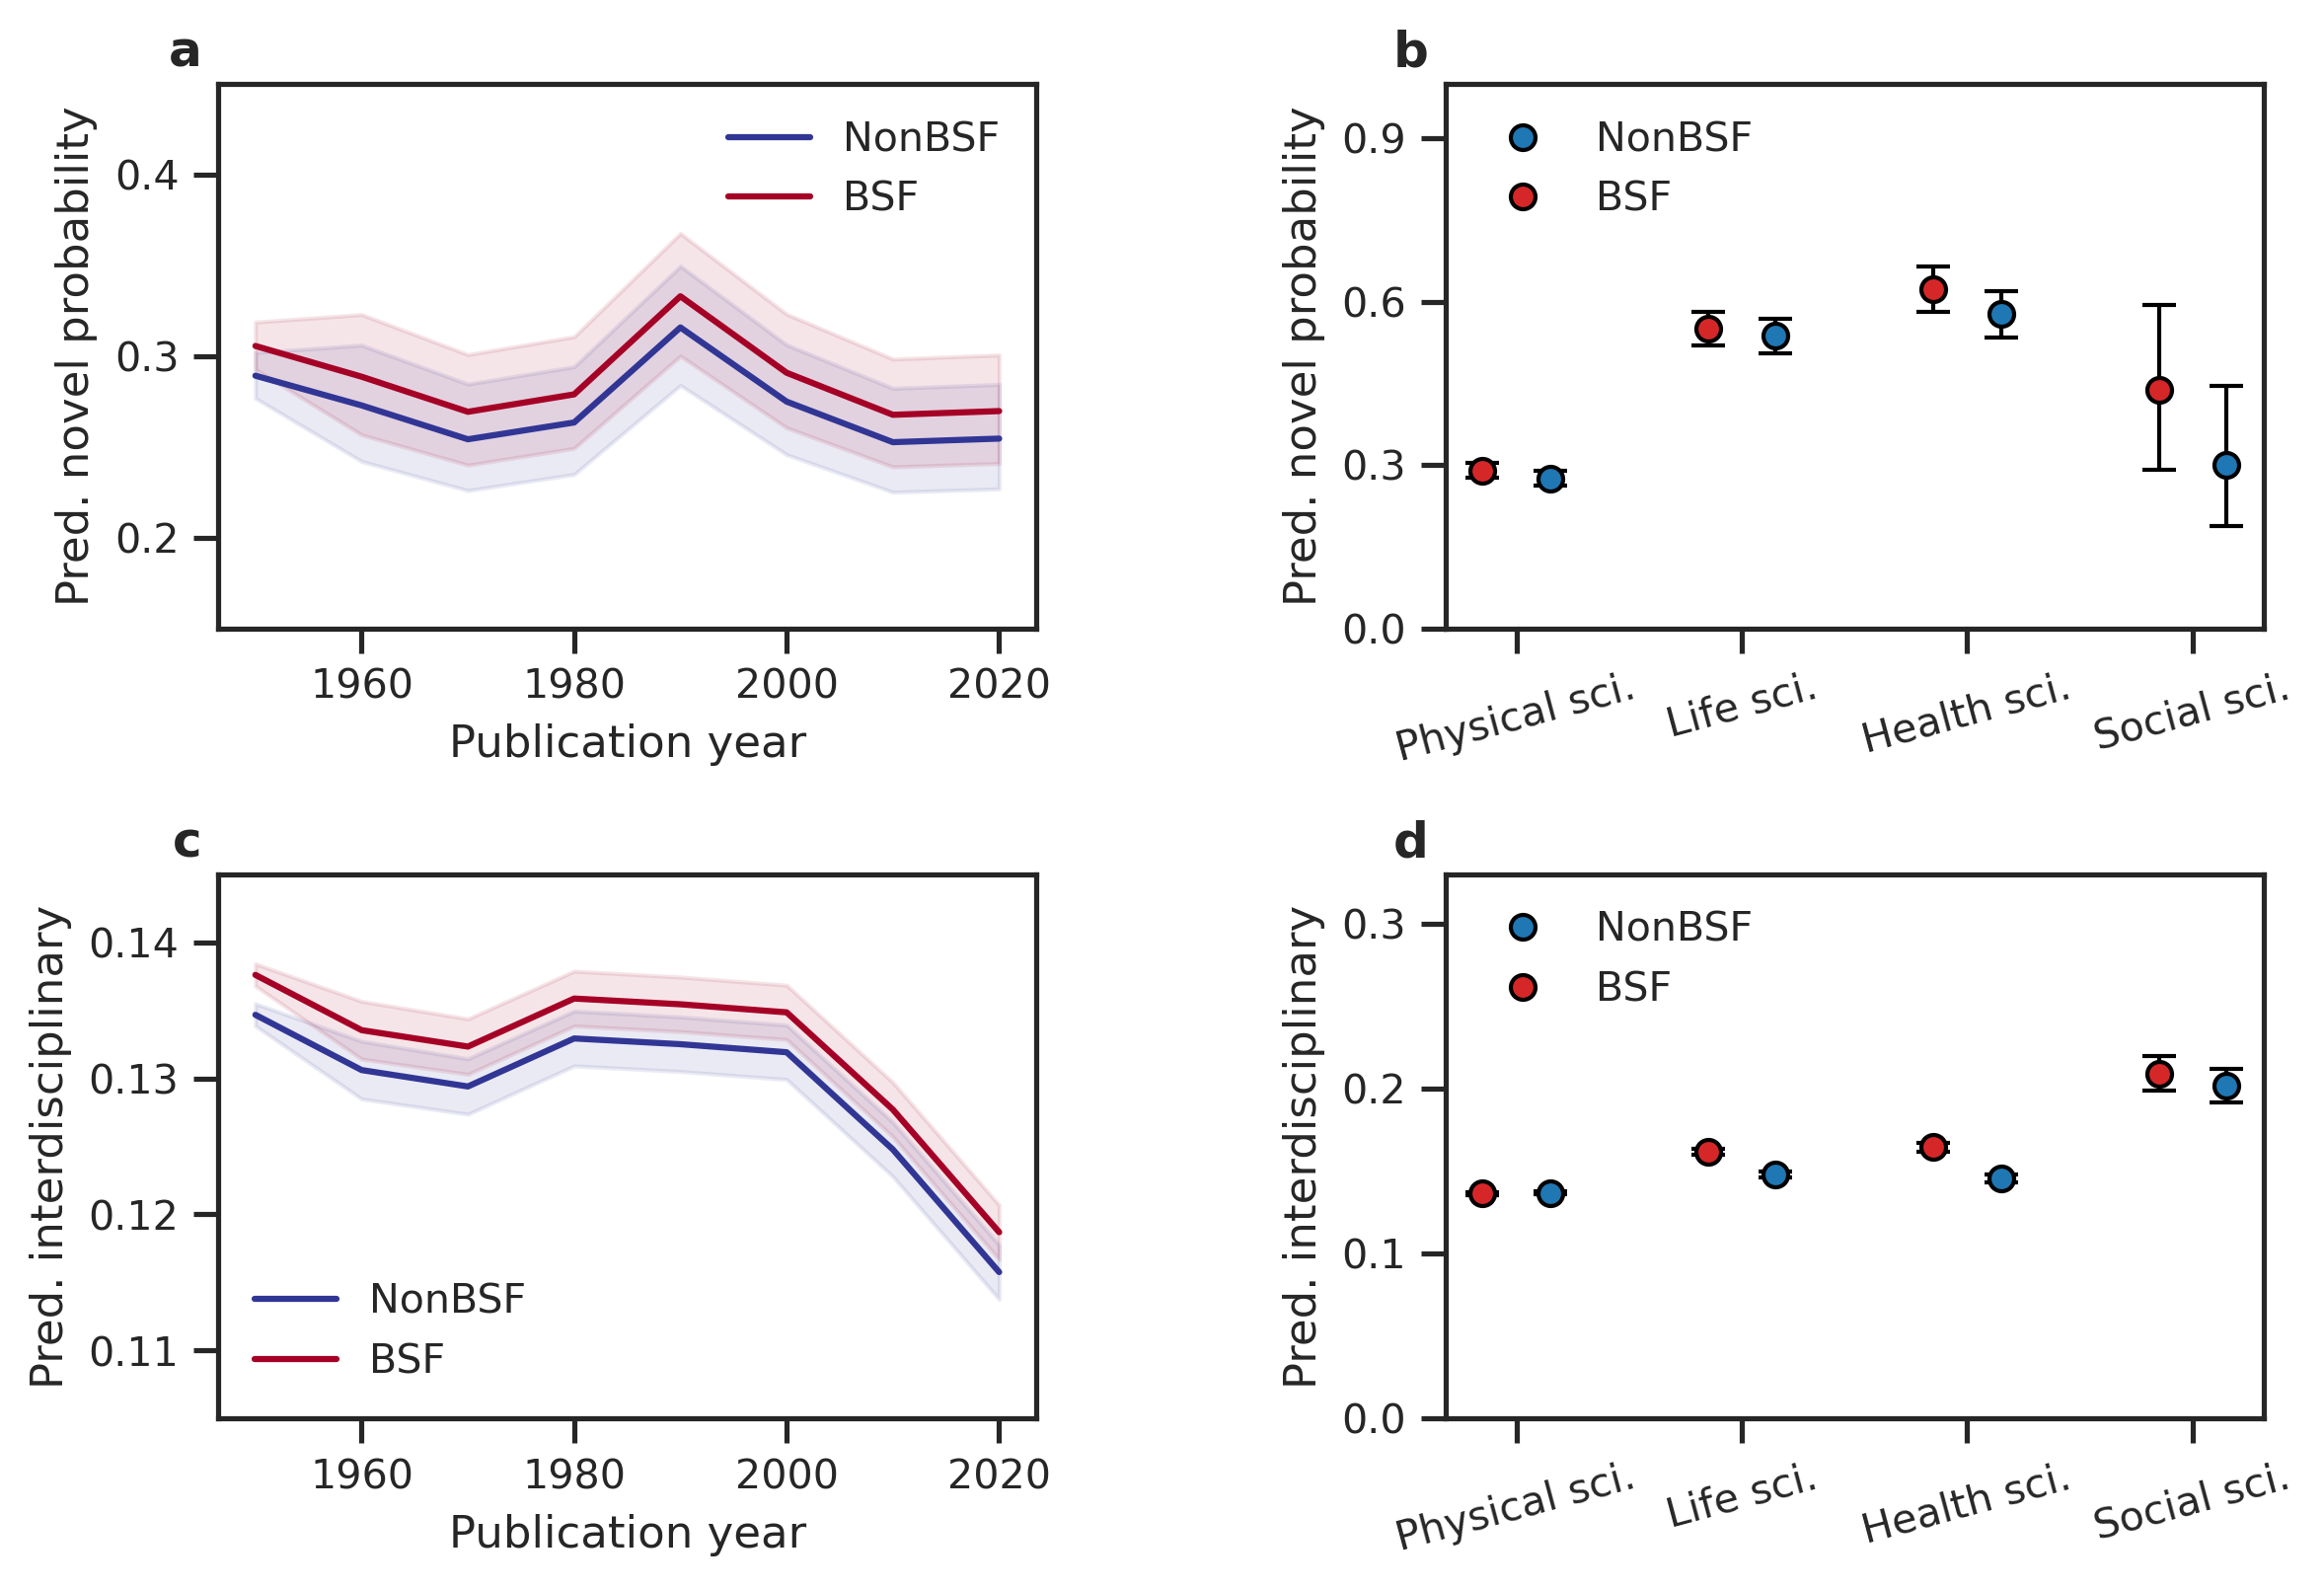

In [15]:
fig = plt.figure(figsize=(8, 5.5), dpi=300)
sns.set(style='ticks', font_scale=0.9)
outer = gridspec.GridSpec(2, 1, height_ratios=[1, 1])
# colors = ['#313695', '#a50026']
color_group = {'BSF':'#a50026', 'NonBSF':'#313695'}
gs1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], width_ratios=[1,1], wspace=0.5)
ax_a = fig.add_subplot(gs1[0])
df = nd
for group in df['x'].unique():
    df1 = df[df['x']==group]
    ax_a.plot(df1['group'], df1['predicted'], linewidth=1.5, label = group, color = color_group[group])
    ax_a.fill_between(df1['group'], df1['conf.low'], df1['conf.high'], color = color_group[group], alpha=0.1)

ax_a.set_ylabel('Pred. novel probability')
ax_a.set_xlabel('Publication year')
ax_a.set_ylim(0.15, 0.45)
ax_a.yaxis.set_major_locator(MultipleLocator(0.1))
ax_a.legend(frameon = False)

ax_b = fig.add_subplot(gs1[1])
df = n
df['err_low'] = df['predicted'] - df['conf.low']
df['err_high'] = df['conf.high'] - df['predicted']
groups = ["ps", "ls", "hs", "ss"]
fac_levels = ["BSF", "NonBSF"]
# 颜色区分 fac_pub
fac_colors = {"NonBSF": "#1f77b4", "BSF": "#d62728"}
x_positions = []
y_values = []
y_err_low = []
y_err_high = []
colors = []
offset = [-0.15, 0.15]
for gi, g in enumerate(groups):
    base_x = gi  # group 在 x-axis 的位置
    df_g = df[df["group"] == g].set_index("x").loc[fac_levels]
    for fi, f in enumerate(fac_levels):
        x = base_x + offset[fi]
        row = df_g.loc[f]
        x_positions.append(x)
        y_values.append(row["predicted"])
        y_err_low.append(row["err_low"])
        y_err_high.append(row["err_high"])
        colors.append(fac_colors[f])
for x, y, ylow, yhigh, c in zip(x_positions, y_values, y_err_low, y_err_high, colors):
    ax_b.errorbar(
        x, y,
        yerr=[[ylow], [yhigh]],
        fmt='o',
        color=c,          # 点颜色
        markerfacecolor=c,
        markeredgecolor='black',
        ecolor='black',   # 误差线颜色
        capsize=4,
        markersize=6,
        linewidth=1
    )
# X 轴
ax_b.set_xticks(range(len(groups)))
ax_b.set_xticklabels(['Physical sci.', 'Life sci.', 'Health sci.', 'Social sci.'], rotation = 15)
# ax_b.set_xlim(-0.5,1.5)
ax_b.set_ylabel("Pred. novel probability")
ax_b.set_ylim(0, 1)
ax_b.yaxis.set_major_locator(MultipleLocator(0.3))
# 图例
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='NonBSF',
               markerfacecolor=fac_colors["NonBSF"], markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='BSF',
               markerfacecolor=fac_colors["BSF"], markeredgecolor='black')
]
ax_b.legend(handles=legend_elements, frameon=False, loc = 'upper left')

gs2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], width_ratios=[1,1], wspace=0.5)
ax_c = fig.add_subplot(gs2[0])
df = rd
for group in df['x'].unique():
    df1 = df[df['x']==group]
    ax_c.plot(df1['group'], df1['predicted'], linewidth=1.5, label = group, color = color_group[group])
    ax_c.fill_between(df1['group'], df1['conf.low'], df1['conf.high'], color = color_group[group], alpha=0.1)

ax_c.set_ylabel('Pred. interdisciplinary')
ax_c.set_xlabel('Publication year')
ax_c.set_ylim(0.105, 0.145)
ax_c.yaxis.set_major_locator(MultipleLocator(0.01))
ax_c.legend(frameon = False, loc = 'lower left')


ax_d = fig.add_subplot(gs2[1])
df = r
df['err_low'] = df['predicted'] - df['conf.low']
df['err_high'] = df['conf.high'] - df['predicted']
groups = ["ps", "ls", "hs", "ss"]
fac_levels = ["BSF", "NonBSF"]
# 颜色区分 fac_pub
fac_colors = {"NonBSF": "#1f77b4", "BSF": "#d62728"}
x_positions = []
y_values = []
y_err_low = []
y_err_high = []
colors = []
offset = [-0.15, 0.15]
for gi, g in enumerate(groups):
    base_x = gi  # group 在 x-axis 的位置
    df_g = df[df["group"] == g].set_index("x").loc[fac_levels]
    for fi, f in enumerate(fac_levels):
        x = base_x + offset[fi]
        row = df_g.loc[f]
        x_positions.append(x)
        y_values.append(row["predicted"])
        y_err_low.append(row["err_low"])
        y_err_high.append(row["err_high"])
        colors.append(fac_colors[f])
for x, y, ylow, yhigh, c in zip(x_positions, y_values, y_err_low, y_err_high, colors):
    ax_d.errorbar(
        x, y,
        yerr=[[ylow], [yhigh]],
        fmt='o',
        color=c,          # 点颜色
        markerfacecolor=c,
        markeredgecolor='black',
        ecolor='black',   # 误差线颜色
        capsize=4,
        markersize=6,
        linewidth=1
    )
# X 轴
ax_d.set_xticks(range(len(groups)))
ax_d.set_xticklabels(['Physical sci.', 'Life sci.', 'Health sci.', 'Social sci.'], rotation = 15)
# ax_b.set_xlim(-0.5,1.5)
ax_d.set_ylabel("Pred. interdisciplinary")
ax_d.set_ylim(0, 0.33)
ax_d.yaxis.set_major_locator(MultipleLocator(0.1))
# 图例
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='NonBSF',
               markerfacecolor=fac_colors["NonBSF"], markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='BSF',
               markerfacecolor=fac_colors["BSF"], markeredgecolor='black')
]
ax_d.legend(handles=legend_elements, frameon=False, loc = 'upper left')

ax_num = [ax_a, ax_b, ax_c, ax_d]
labels = list(string.ascii_lowercase)
for i, ax in enumerate(ax_num):
    ax.text(-0.02, 1.1, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')
plt.tight_layout()
plt.savefig(main_path + r'UseBSForNot/Figure5-Heterogenous.tif',bbox_inches='tight')
plt .show()